In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [17]:
def quadruple(y):
    ''' Quadruple y '''
    return 4*y

In [12]:
quadruple?

Signature: quadruple(y)
Docstring: Quadruple y 
File:      c:\users\ln015\appdata\local\temp\ipykernel_27884\2015895397.py
Type:      function

In [20]:
quadruple(42)

168

In [13]:
quadruple(3.14)

12.56

In [15]:
quadruple('hi mom')

'hi momhi momhi momhi mom'

In [21]:
quadruple(make_array(4, 5, 6))

array([16, 20, 24])

In [16]:
y

NameError: name 'y' is not defined

In [29]:
def percents(counts):
    '''Converts the values in counts to percents out of the total.'''
    total = sum(counts) 
    return np.round(counts / total * 100, 2)

In [30]:
percents(make_array(20, 25, 30))

array([ 26.67,  33.33,  40.  ])

In [32]:
def percents(counts, decimal_places):
    '''Converts the values in counts to percents out of the total.'''
    total = sum(counts) 
    return np.round(counts / total * 100, decimal_places)

In [33]:
percents(make_array(20, 25, 30), 3)

array([ 26.667,  33.333,  40.   ])

In [34]:
percents(make_array(20, 25, 30))

TypeError: percents() missing 1 required positional argument: 'decimal_places'

In [16]:
def percents(counts, decimal_places=2):
    '''Converts the values in counts to percents out of the total.'''
    total = sum(counts) 
    return np.round(counts / total * 100, decimal_places)

In [36]:
percents(make_array(20, 25, 30))

array([ 26.67,  33.33,  40.  ])

In [37]:
percents(make_array(20, 25, 30), 3)

array([ 26.667,  33.333,  40.   ])

# Applying functions to Tables

In [38]:
places = Table().with_columns(
    'Place', make_array('Fresno', 'Death Valley', 'Shaver Lake'),
    'Elevation', make_array(308, -282, 5627)
)
places

Place,Elevation
Fresno,308
Death Valley,-282
Shaver Lake,5627


In [39]:
def cut_off_at_0(val):
    return max(0, val)

In [40]:
cut_off_at_0(-5), cut_off_at_0(0), cut_off_at_0(42)

(0, 0, 42)

In [41]:
places.apply(cut_off_at_0, 'Elevation')

array([ 308,    0, 5627])

In [42]:
places.with_column('Cut off elevation', places.apply(cut_off_at_0, 'Elevation'))

Place,Elevation,Cut off elevation
Fresno,308,308
Death Valley,-282,0
Shaver Lake,5627,5627


In [43]:
cut_off_at_0

<function __main__.cut_off_at_0(val)>

In [44]:
cut = cut_off_at_0

In [45]:
cut(-5)

0

In [46]:
cut_off_at_0(42)

42

In [50]:
def calculate_total(price, tax_rate):
    result = price * (tax_rate / 100) + price
    return round(result, 2)

In [51]:
calculate_total(5.99, 8.35)

6.49

In [52]:
calculate_total(7.99, 8.75)

8.69

# Prediction

In [54]:
family_heights = Table.read_table('data/family_heights.csv').drop(3)
family_heights

family,father,mother,children,childNum,sex,childHeight
1,78.5,67,4,1,male,73.2
1,78.5,67,4,2,female,69.2
1,78.5,67,4,3,female,69
1,78.5,67,4,4,female,69
2,75.5,66.5,4,1,male,73.5
2,75.5,66.5,4,2,male,72.5
2,75.5,66.5,4,3,female,65.5
2,75.5,66.5,4,4,female,65.5
3,75,64,2,1,male,71
3,75,64,2,2,female,68


In [56]:
parent_averages = (family_heights.column('father') + family_heights.column('mother')) / 2
heights = Table().with_columns(
    'Parent Average', parent_averages,
    'Child', family_heights.column('childHeight')
)
heights

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5
71,72.5
71,65.5
71,65.5
69.5,71
69.5,68


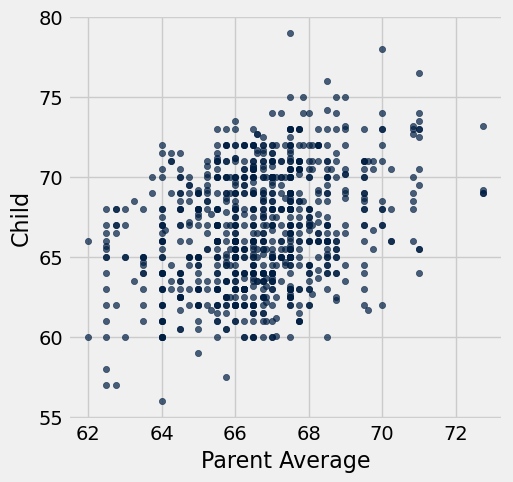

In [57]:
heights.scatter('Parent Average')

In [60]:
close_to_66 = heights.where('Parent Average', are.between(65.5, 66.5))
close_to_66

Parent Average,Child
66,62
66.25,72
66.25,70
66.25,69.5
66.25,69.5
66.25,68
66.25,65
66.25,64
66.25,63
66.25,72


In [62]:
min(close_to_66.column('Child')), max(close_to_66.column('Child'))

(57.5, 73.5)

In [63]:
np.average(close_to_66.column('Child'))

66.086407766990291

In [64]:
def predict_child(p_avg):
    close_points = heights.where('Parent Average', are.between(p_avg - 0.5, p_avg + 0.5))
    return np.average(close_points.column('Child'))

In [65]:
predict_child(66)

66.086407766990291

In [66]:
predict_child(70)

68.561904761904756

In [70]:
heights_with_predictions = heights.with_column(
    'Prediction', heights.apply(predict_child, 'Parent Average')
)
heights_with_predictions

Parent Average,Child,Prediction
72.75,73.2,70.1
72.75,69.2,70.1
72.75,69,70.1
72.75,69,70.1
71,73.5,70.4158
71,72.5,70.4158
71,65.5,70.4158
71,65.5,70.4158
69.5,71,68.5025
69.5,68,68.5025


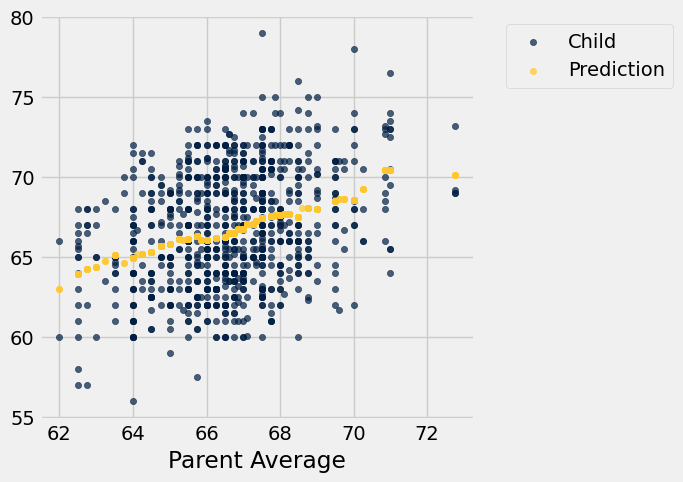

In [71]:
heights_with_predictions.scatter('Parent Average')

# Grouping

In [72]:
cones = Table.read_table('data/cones.csv')
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
vanilla,white,3.5
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [73]:
cones.group('Flavor')

Flavor,count
bubblegum,1
chocolate,3
strawberry,2
vanilla,1


In [75]:
cones.group('Flavor', np.average)

Flavor,Color average,Price average
bubblegum,,4.75
chocolate,,5.08333
strawberry,,4.4
vanilla,,3.5


In [76]:
cones.group('Flavor', list)

Flavor,Color list,Price list
bubblegum,['pink'],[4.75]
chocolate,"['light brown', 'dark brown', 'dark brown']","[4.75, 5.25, 5.25]"
strawberry,"['pink', 'pink']","[3.5499999999999998, 5.25]"
vanilla,['white'],[3.5]


In [77]:
cones.group('Flavor', sum)

Flavor,Color sum,Price sum
bubblegum,,4.75
chocolate,,15.25
strawberry,,8.8
vanilla,,3.5


In [80]:
cones.drop('Color').group('Flavor', max)

Flavor,Price max
bubblegum,4.75
chocolate,5.25
strawberry,5.25
vanilla,3.5


In [81]:
pokemon = Table.read_table('data/pokemon.csv')
pokemon

abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,nan,8.5,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,nan,19,1,0
"['Blaze', 'Solar Power']",0.25,1,1,2,0.5,0.5,0.5,1,1,0.25,0,1,1,1,1,4,0.5,2,104,5120,70,634,45,Flame Pokémon,78,1059860,1.7,78,Lizardonリザードン,Charizard,88.1,6,159,115,100,fire,flying,90.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,48,5120,70,314,45,Tiny Turtle Pokémon,65,1059860,0.5,44,Zenigameゼニガメ,Squirtle,88.1,7,50,64,43,water,nan,9,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,63,5120,70,405,45,Turtle Pokémon,80,1059860,1,59,Kameilカメール,Wartortle,88.1,8,65,80,58,water,nan,22.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,103,5120,70,630,45,Shellfish Pokémon,120,1059860,1.6,79,Kamexカメックス,Blastoise,88.1,9,135,115,78,water,nan,85.5,1,0
"['Shield Dust', 'Run Away']",1,1,1,1,1,0.5,2,2,1,0.5,0.5,1,1,1,1,2,1,1,30,3840,70,195,255,Worm Pokémon,35,1000000,0.3,45,Caterpieキャタピー,Caterpie,50,10,20,20,45,bug,nan,2.9,1,0


In [83]:
p = pokemon.select('type1', 'hp')
p

type1,hp
grass,45
grass,60
grass,80
fire,39
fire,58
fire,78
water,44
water,59
water,79
bug,45


In [84]:
p.group('type1', list)

type1,hp list
bug,"[45, 50, 60, 40, 45, 65, 35, 60, 60, 70, 70, 65, 40, 55, ..."
dark,"[95, 60, 55, 45, 75, 35, 70, 50, 65, 100, 70, 70, 41, 64 ..."
dragon,"[41, 61, 91, 75, 45, 65, 95, 80, 80, 105, 58, 68, 108, 4 ..."
electric,"[35, 60, 25, 50, 40, 60, 65, 65, 90, 20, 55, 70, 90, 45, ..."
fairy,"[70, 95, 50, 35, 55, 60, 90, 85, 44, 74, 78, 78, 101, 62 ..."
fighting,"[40, 65, 70, 80, 90, 50, 50, 35, 50, 72, 144, 30, 60, 40 ..."
fire,"[39, 58, 78, 38, 73, 55, 90, 50, 65, 65, 65, 90, 39, 58, ..."
flying,"[79, 40, 85]"
ghost,"[30, 45, 60, 60, 44, 64, 20, 40, 90, 150, 60, 50, 45, 15 ..."
grass,"[45, 60, 80, 45, 60, 75, 50, 65, 80, 60, 95, 65, 45, 60, ..."


In [86]:
p.group('type1', np.average).sort('hp average', descending=True)

type1,hp average
dragon,79.8519
normal,76.7238
fairy,73.9444
ground,73.1875
psychic,72.9434
dark,72.5517
ice,72.087
fighting,71.4286
water,70.2193
fire,68.7308


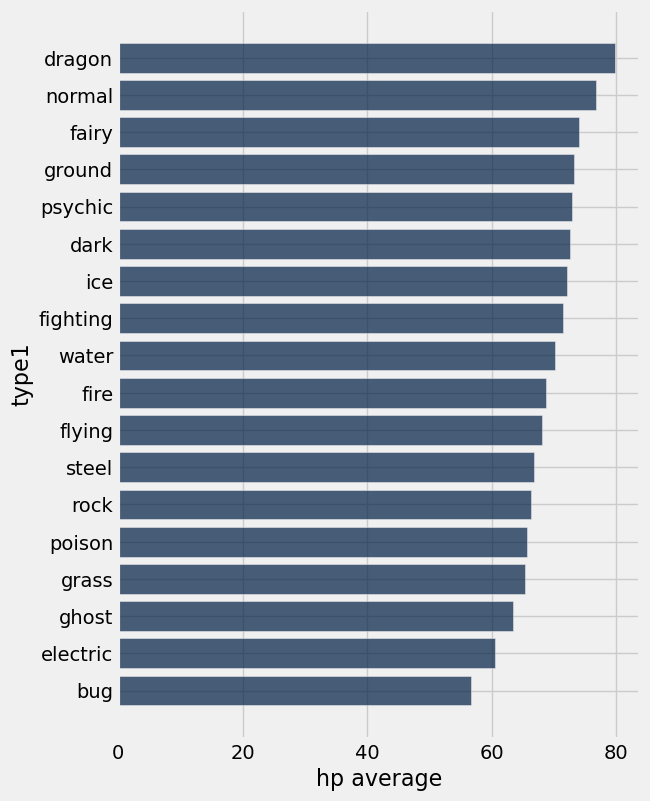

In [87]:
p.group('type1', np.average).sort('hp average', descending=True).barh('type1')

In [88]:
pokemon

abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,nan,8.5,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,nan,19,1,0
"['Blaze', 'Solar Power']",0.25,1,1,2,0.5,0.5,0.5,1,1,0.25,0,1,1,1,1,4,0.5,2,104,5120,70,634,45,Flame Pokémon,78,1059860,1.7,78,Lizardonリザードン,Charizard,88.1,6,159,115,100,fire,flying,90.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,48,5120,70,314,45,Tiny Turtle Pokémon,65,1059860,0.5,44,Zenigameゼニガメ,Squirtle,88.1,7,50,64,43,water,nan,9,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,63,5120,70,405,45,Turtle Pokémon,80,1059860,1,59,Kameilカメール,Wartortle,88.1,8,65,80,58,water,nan,22.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,103,5120,70,630,45,Shellfish Pokémon,120,1059860,1.6,79,Kamexカメックス,Blastoise,88.1,9,135,115,78,water,nan,85.5,1,0
"['Shield Dust', 'Run Away']",1,1,1,1,1,0.5,2,2,1,0.5,0.5,1,1,1,1,2,1,1,30,3840,70,195,255,Worm Pokémon,35,1000000,0.3,45,Caterpieキャタピー,Caterpie,50,10,20,20,45,bug,nan,2.9,1,0


In [89]:
pokemon.group('type1', np.average) # too much info!

type1,abilities average,against_bug average,against_dark average,against_dragon average,against_electric average,against_fairy average,against_fight average,against_fire average,against_flying average,against_ghost average,against_grass average,against_ground average,against_ice average,against_normal average,against_poison average,against_psychic average,against_rock average,against_steel average,against_water average,attack average,base_egg_steps average,base_happiness average,base_total average,capture_rate average,classfication average,defense average,experience_growth average,height_m average,hp average,japanese_name average,name average,percentage_male average,pokedex_number average,sp_attack average,sp_defense average,speed average,type2 average,weight_kg average,generation average,is_legendary average
bug,,0.826389,0.979167,0.9375,1.13889,0.916667,0.458333,2.19444,2.08333,1.01389,0.420139,0.5625,1.20833,0.930556,0.930556,1.15972,2.29167,0.972222,1.02083,70.125,5617.78,67.0833,380.431,,,70.8472,1.00901e+06,0.883333,56.7222,,,nan,395.917,56.6528,62.5139,63.5694,,33.0833,3.76389,0.0416667
dark,,1.72414,0.534483,1.10345,1.10345,2.27586,1.96552,1.03448,1.03448,0.551724,0.775862,0.965517,1.2069,0.931034,0.913793,0,1.24138,1,1,87.7931,8386.21,42.2414,449.759,,,70.5172,1.10272e+06,1.29655,72.5517,,,nan,490.034,74.5172,69.069,75.3103,,69.0966,4.27586,0.103448
dragon,,0.944444,1.03704,2,0.490741,2.11111,0.925926,0.509259,1.05556,1.07407,0.527778,0.925926,2.51852,1,0.925926,1.03704,1.11111,1,0.592593,106.407,15265.2,42.963,522.778,,,86.2593,1.21667e+06,1.93704,79.8519,,,nan,516.296,89.5926,84.5556,76.1111,,107.126,4.2963,0.259259
electric,,0.871795,1,0.897436,0.538462,0.948718,1.0641,1.10256,0.474359,0.974359,0.910256,2.05128,1.02564,0.923077,0.935897,0.948718,1.02564,0.5,1,70.8205,7056.41,68.4615,436.154,,,61.8205,1.07331e+06,nan,60.5128,,,nan,380.103,87.5385,70.0513,85.4103,,nan,3.46154,0.128205
fairy,,0.472222,0.5,0,1.11111,1,0.472222,1,1,1,0.944444,0.888889,1.11111,1,2,1,1.11111,2,1,62.1111,5902.22,77.7778,427.167,,,68.1667,913889,0.794444,73.9444,,,nan,467,81.5,87.7778,53.6667,,23.5556,4.27778,0.0555556
fighting,,0.535714,0.526786,0.982143,1.03571,2.03571,1.05357,1.07143,1.96429,1.05357,0.964286,1,1,0.982143,0.964286,1.82143,0.526786,1.01786,1,99.1786,5577.14,70,414.821,,,66.3929,1.07602e+06,1.19643,71.4286,,,70.6929,404.036,50.1071,63.4286,64.2857,,58.675,3.75,0
fire,,0.456731,0.951923,1.00962,1.08654,0.572115,1.02885,0.495192,1.09615,0.971154,0.5,1.84615,0.576923,0.980769,0.951923,1.07692,2.05769,0.5,2.07692,81.5,6670.77,68.4615,450.635,,,67.7885,1.06474e+06,nan,68.7308,,,nan,376.404,87.7308,71.5385,73.3462,,nan,3.63462,0.0961538
flying,,0.5,1,1.66667,1.33333,1.66667,0.5,0.666667,1,1,0.333333,0,3.33333,1,1,1,2,1,0.666667,66.6667,13653.3,76.6667,453.333,,,65,1.08333e+06,1.16667,68,,,66.6667,690,84,70,99.6667,,52,5.66667,0.333333
ghost,,0.527778,1.92593,1,0.888889,0.962963,0,1.11111,1.18519,1.96296,0.814815,1.05556,1.31481,0,0.564815,1.07407,1.14815,0.981481,1.07407,72.7407,6731.85,58.3333,434.704,,,79.5185,1.01812e+06,1.25185,63.3704,,,nan,498.815,82.4444,78.2963,58.3333,,69.5704,4.37037,0.037037
grass,,1.71795,0.967949,0.916667,0.532051,0.967949,0.916667,2.12821,2.03846,1.01923,0.432692,0.570513,2.11538,0.967949,1.84615,1.14744,1.05769,1.07051,0.50641,73.7692,5907.69,67.6923,412.577,,,70.8718,1.07979e+06,nan,65.359,,,nan,410.128,74.3205,69.2308,59.0256,,nan,3.9359,0.0512821


In [90]:
pokemon.group('type1')

type1,count
bug,72
dark,29
dragon,27
electric,39
fairy,18
fighting,28
fire,52
flying,3
ghost,27
grass,78


In [91]:
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
vanilla,white,3.5
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [93]:
cones.group(make_array('Flavor', 'Color'))

Flavor,Color,count
bubblegum,pink,1
chocolate,dark brown,2
chocolate,light brown,1
strawberry,pink,2
vanilla,white,1


In [94]:
cones.group(make_array('Flavor', 'Color'), min)

Flavor,Color,Price min
bubblegum,pink,4.75
chocolate,dark brown,5.25
chocolate,light brown,4.75
strawberry,pink,3.55
vanilla,white,3.5


In [95]:
cones.group(['Flavor', 'Color'], min)

Flavor,Color,Price min
bubblegum,pink,4.75
chocolate,dark brown,5.25
chocolate,light brown,4.75
strawberry,pink,3.55
vanilla,white,3.5


---

In [2]:
cones = Table.read_table('data/cones.csv')
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
vanilla,white,3.5
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [3]:
cones.pivot('Flavor', 'Color')

Color,bubblegum,chocolate,strawberry,vanilla
dark brown,0,2,0,0
light brown,0,1,0,0
pink,1,0,2,0
white,0,0,0,1


In [4]:
cones.pivot('Flavor', 'Color', values='Price', collect=np.average)

Color,bubblegum,chocolate,strawberry,vanilla
dark brown,0,5.25,0,0
light brown,0,4.75,0,0
pink,4.75,0,4.4,0
white,0,0,0,3.5


In [5]:
cones.group(['Flavor', 'Color'], np.average)

Flavor,Color,Price average
bubblegum,pink,4.75
chocolate,dark brown,5.25
chocolate,light brown,4.75
strawberry,pink,4.4
vanilla,white,3.5


In [9]:
education_income = Table.read_table('data/educ_inc.csv')
educ2014 = education_income.where('Year', '1/1/14 0:00').where('Age', are.not_equal_to('00 to 17'))
educ2014

Year,Age,Gender,Educational Attainment,Personal Income,Population Count
1/1/14 0:00,18 to 64,Female,No high school diploma,"H: 75,000 and over",2058
1/1/14 0:00,65 to 80+,Male,No high school diploma,"H: 75,000 and over",2153
1/1/14 0:00,65 to 80+,Female,No high school diploma,"G: 50,000 to 74,999",4666
1/1/14 0:00,65 to 80+,Female,High school or equivalent,"H: 75,000 and over",7122
1/1/14 0:00,65 to 80+,Female,No high school diploma,"F: 35,000 to 49,999",7261
1/1/14 0:00,65 to 80+,Male,No high school diploma,"G: 50,000 to 74,999",8569
1/1/14 0:00,18 to 64,Female,No high school diploma,"G: 50,000 to 74,999",14635
1/1/14 0:00,65 to 80+,Male,No high school diploma,"F: 35,000 to 49,999",15212
1/1/14 0:00,65 to 80+,Male,"College, less than 4-yr degree","B: 5,000 to 9,999",15423
1/1/14 0:00,65 to 80+,Female,Bachelor's degree or higher,"A: 0 to 4,999",15459


In [11]:
educ2014 = educ2014.select(3, 4, 5)
educ2014

Educational Attainment,Personal Income,Population Count
No high school diploma,"H: 75,000 and over",2058
No high school diploma,"H: 75,000 and over",2153
No high school diploma,"G: 50,000 to 74,999",4666
High school or equivalent,"H: 75,000 and over",7122
No high school diploma,"F: 35,000 to 49,999",7261
No high school diploma,"G: 50,000 to 74,999",8569
No high school diploma,"G: 50,000 to 74,999",14635
No high school diploma,"F: 35,000 to 49,999",15212
"College, less than 4-yr degree","B: 5,000 to 9,999",15423
Bachelor's degree or higher,"A: 0 to 4,999",15459


In [14]:
totals = educ2014.pivot('Educational Attainment', 'Personal Income', values='Population Count', collect=sum)
totals

Personal Income,Bachelor's degree or higher,"College, less than 4-yr degree",High school or equivalent,No high school diploma
"A: 0 to 4,999",575491,985011,1161873,1204529
"B: 5,000 to 9,999",326020,810641,626499,597039
"C: 10,000 to 14,999",452449,798596,692661,664607
"D: 15,000 to 24,999",773684,1345257,1252377,875498
"E: 25,000 to 34,999",693884,1091642,929218,464564
"F: 35,000 to 49,999",1122791,1112421,782804,260579
"G: 50,000 to 74,999",1594681,883826,525517,132516
"H: 75,000 and over",2986698,748103,323192,58945


In [20]:
dist = totals.select(0).with_columns(
    "Bachelor's degree or higher", percents(totals.column(1)),
    "No high school diploma", percents(totals.column(4))
)
dist

Personal Income,Bachelor's degree or higher,No high school diploma
"A: 0 to 4,999",6.75,28.29
"B: 5,000 to 9,999",3.82,14.02
"C: 10,000 to 14,999",5.31,15.61
"D: 15,000 to 24,999",9.07,20.56
"E: 25,000 to 34,999",8.14,10.91
"F: 35,000 to 49,999",13.17,6.12
"G: 50,000 to 74,999",18.7,3.11
"H: 75,000 and over",35.03,1.38


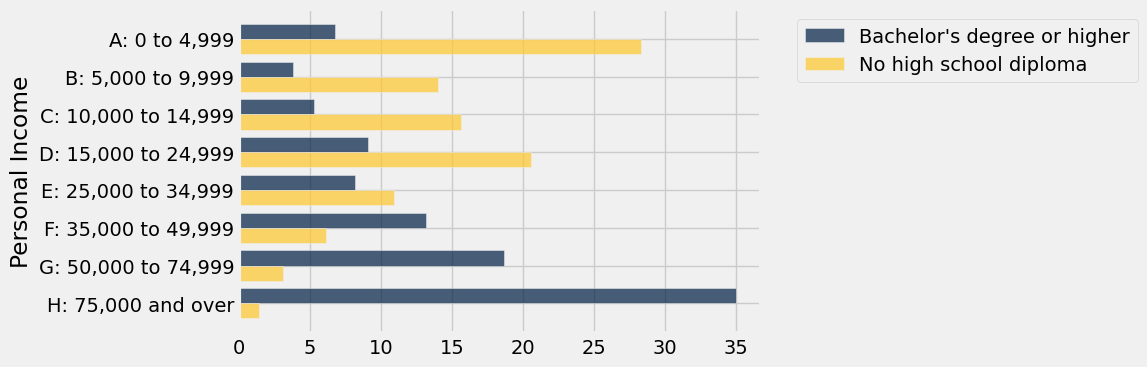

In [22]:
dist.barh(0)